# Tabular classification with Amazon SageMaker LightGBM and CatBoost algorithm (V3)

---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

---

> **SageMaker Python SDK v3 note:** This notebook has been migrated to the SageMaker Python SDK **v3**. The JumpStart LightGBM/CatBoost tabular-classification workflow now uses the high-level v3 JumpStart training API `ModelTrainer.from_jumpstart_config(...)` (from `sagemaker-train`) wrapped by the v3 `HyperparameterTuner` (from `sagemaker.train.tuner`) for Automatic Model Tuning, and deploys the best tuning job with `sagemaker-core` resource classes (`Model`/`EndpointConfig`/`Endpoint`). It no longer uses the v2 generic `Estimator`, `sagemaker.tuner`, or the top-level `image_uris`/`model_uris`/`script_uris` helpers (these now live under `sagemaker.core`). Install with `pip install sagemaker` (v3).

---

---
This notebook demonstrates the use of Amazon SageMaker’s implementation of the [LightGBM](https://lightgbm.readthedocs.io/en/latest/) and [CatBoost](https://catboost.ai/en/docs/) algorithm to train and host a tabular multiclass classification model. Tabular classification is the task of assigning a class to an example of structured or relational data. The Amazon SageMaker API for tabular classification can be used for classification of an example in two classes (binary classification) or more than two classes (multi-class classification).


In this notebook, we demonstrate two use cases of tabular classification models:

* How to train a tabular model on an example dataset to do multi-class classification.
* How to use the trained tabular model to perform inference, i.e., classifying new samples.

Note: This notebook was tested in Amazon SageMaker Studio on ml.t3.medium instance with Python 3 (Data Science) kernel.

---

1. [Set Up](#1.-Set-Up)
2. [Train A Tabular Model on MNIST Dataset](#2.-Train-a-Tabular-Model-on-MNIST-Dataset)
    * [Retrieve Training Artifacts](#2.1.-Retrieve-Training-Artifacts)
    * [Set Training Parameters](#2.2.-Set-Training-Parameters)
    * [Train with Automatic Model Tuning](#2.3.-Train-with-Automatic-Model-Tuning)   
    * [Start Training](#2.4.-Start-Training)
3. [Deploy and Run Inference on the Trained Tabular Model](#3.-Deploy-and-Run-Inference-on-the-Trained-Tabular-Model)
4. [Evaluate the Prediction Results Returned from the Endpoint](#4.-Evaluate-the-Prediction-Results-Returned-from-the-Endpoint)

## 1. Set Up

---
Before executing the notebook, there are some initial steps required for setup. This notebook requires latest version of sagemaker and ipywidgets.

---

In [1]:
# [papermill-run] pip install disabled to preserve local env
pass


---
To train and host on Amazon SageMaker, we need to setup and authenticate the use of AWS services. Here, we use the execution role associated with the current notebook instance as the AWS account role with SageMaker access. It has necessary permissions, including access to your data in S3.

---

In [2]:
import boto3, json
from sagemaker.core.helper.session_helper import Session, get_execution_role
import boto3 as _boto3
sess = Session(boto_session=_boto3.Session(region_name="us-west-1"))  # [papermill-run] region-bound session
aws_role = "arn:aws:iam::729646638167:role/SageMakerRole"  # [papermill-run] explicit role
aws_region = sess.boto_region_name

[07/13/26 13:50:06] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7300135;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7300136;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


## 2. Train a Tabular Model on MNIST Dataset

---
In this demonstration, we will train a tabular algorithm on the
[MNIST](http://yann.lecun.com/exdb/mnist/) dataset. 
The dataset contains examples of individual pixel values from each 28 x 28 grayscale image to predict the digit label of 10 classes {0, 1, 2, 3, ..., 9}. The MNIST dataset is downloaded from [THE MNIST DATABASE](http://yann.lecun.com/exdb/mnist/). 

Below is the table of the first 5 examples in the MNIST dataset.

| Target | Feature_0 | Feature_1 | Feature_2 | ... | Feature_291 | Feature_293 | Feature_294 | ... | Feature_783 |  Feature_784  |
|:------:|:---------:|:---------:|:---------:|:---:|:-----------:|:-----------:|:-----------:|:---:|:-----------:|:-------------:|
|   7    |    0.0    |    0.0    |    0.0    | ... |   0.00000   |   0.25781   |   0.05469   | ... |     0.0     |      0.0      |
|   2    |    0.0    |    0.0    |    0.0    | ... |   0.00000   |   0.29687   |   0.96484   | ... |     0.0     |      0.0      |
|   1    |    0.0    |    0.0    |    0.0    | ... |   0.00000   |   0.00000   |   0.00000   | ... |     0.0     |      0.0      |
|   0    |    0.0    |    0.0    |    0.0    | ... |   0.98828   |   0.98046   |   0.98046   | ... |     0.0     |      0.0      |
|   4    |    0.0    |    0.0    |    0.0    | ... |   0.20703   |   0.00000   |   0.00000   | ... |     0.0     |      0.0      |

If you want to bring your own dataset, below are the instructions on how the training data should be formatted as input to the model.

A S3 path should contain two sub-directories 'train/', 'validation/' (optional), and a json-format file named 'categorical_index.json' (optional). Each sub-directory contains a 'data.csv' file (The MNIST dataset used in this example has been prepared and saved in `training_dataset_s3_path` shown below).
* The 'data.csv' files under sub-directory 'train/' and 'validation/' are for training and validation, respectively. The validation data is used to compute a validation score at the end of each boosting iteration. An early stopping is applied when the validation score stops improving. If the validation data is not provided, a 20% of training data is randomly sampled to serve as the validation data. 

* The first column of the 'data.csv' should have the corresponding target variable. The rest of other columns should have the corresponding predictor variables (features). 

* If the predictors include categorical feature(s), a json-format file named 'categorical_index.json' should be included in the input directory to indicate the column index(es) of the categorical features. Within the json-format file, it should have a python directory where the key is a string of 'cat_index_list' and the value is a list of unique integer(s). Each integer in the list indicates the column index of categorical features in the 'data.csv'. The range of each integer should be more than 0 (index 0 indicates the target) and less than the total number of columns.   

* All the categorical features and the target must be encoded as non-negative integers (```int```) less than ```Int32.MaxValue``` (2147483647). It is best to use a contiguous range of integers started from zero.

* Note. The number of json-format files should be no more than 1 in the input directory.  


Citations:

- [LeCun et al., 1998a] Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner. 'Gradient-based learning applied to document recognition.' Proceedings of the IEEE, 86(11):2278-2324, November 1998

### 2.1. Select the JumpStart Model

___

In v3, we no longer manually retrieve the training container, source code, and pre-trained model artifact. Instead we identify the JumpStart model with a `JumpStartConfig` (specifying the `model_id`), and `ModelTrainer.from_jumpstart_config(...)` resolves the training image, training source code, pre-trained model artifact, and default hyperparameters automatically.

For the training algorithm, we have two choices in this demonstration.
* [LightGBM](https://lightgbm.readthedocs.io/en/latest/): To use this algorithm, specify `train_model_id` as `lightgbm-classification-model` in the cell below.
* [CatBoost](https://catboost.ai/en/docs/): To use this algorithm, specify `train_model_id` as `catboost-classification-model` in the cell below.

___

In [3]:
# Choose the JumpStart tabular classification model: "lightgbm-classification-model"
# or "catboost-classification-model". The v3 ModelTrainer.from_jumpstart_config(...) call
# below resolves the training image, source code, pre-trained artifact and default
# hyperparameters automatically from this model_id.
train_model_id, train_model_version, train_scope = "lightgbm-classification-model", "*", "training"
training_instance_type = "ml.m5.xlarge"

### 2.2. Set Training Parameters

---

Now that we are done with all the setup that is needed, we are ready to train our tabular algorithm. To begin, let us create a [``sageMaker.estimator.Estimator``](https://sagemaker.readthedocs.io/en/stable/api/training/estimators.html) object. This estimator will launch the training job. 

There are two kinds of parameters that need to be set for training. The first one are the parameters for the training job. These include: (i) Training data path. This is S3 folder in which the input data is stored, (ii) Output path: This the s3 folder in which the training output is stored. (iii) Training instance type: This indicates the type of machine on which to run the training.

The second set of parameters are algorithm specific training hyper-parameters. 

---

In [4]:
# Sample training data is available in this bucket
training_data_bucket = f"jumpstart-cache-prod-{aws_region}"
training_data_prefix = "training-datasets/tabular_multiclass/"

training_dataset_s3_path = f"s3://{training_data_bucket}/{training_data_prefix}"

output_bucket = sess.default_bucket()
output_prefix = "jumpstart-example-tabular-training"
default_bucket_prefix = sess.default_bucket_prefix

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    output_prefix = f"{default_bucket_prefix}/{output_prefix}"

s3_output_location = f"s3://{output_bucket}/{output_prefix}/output"

---
For algorithm specific hyper-parameters, we start by fetching python dictionary of the training hyper-parameters that the algorithm accepts with their default values. This can then be overridden to custom values.

---

In [5]:
from sagemaker.core import hyperparameters

# Retrieve the default hyper-parameters for fine-tuning the model
hyperparameters = hyperparameters.retrieve_default(
    model_id=train_model_id, model_version=train_model_version
)

# [Optional] Override default hyperparameters with custom values
hyperparameters["num_boost_round"] = (
    "500"  # The same hyperparameter is named as "iterations" for CatBoost
)
print(hyperparameters)

[07/13/26 13:50:07] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7300141;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7300142;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Using model 'lightgbm-classification-model' with wildcard version identifier '*'. You can pin to version '2.2.15' for more stable results. Note that models may have different input/output signatures after a major version upgrade.


[07/13/26 13:50:08] WARNING  Using model 'lightgbm-classification-model' with wildcard version         ]8;id=7300149;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/cache.py\cache.py]8;;\:]8;id=7300150;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/cache.py#624\624]8;;\
                             identifier '*'. You can pin to version '2.2.15' for more stable results.              
                             Note that models may have different input/output signatures after a major             
                             version upgrade.                                                                      

{'num_boost_round': '500', 'early_stopping_rounds': '30', 'metric': 'auto', 'learning_rate': '0.009', 'num_leaves': '67', 'feature_fraction': '0.74', 'bagging_fraction': '0.53', 'bagging_freq': '5', 'max_depth': '11', 'min_data_in_leaf': '26', 'max_delta_step': '0.0', 'lambda_l1': '0.0', 'lambda_l2': '0.0', 'boosting': 'gbdt', 'min_gain_to_split': '0.0', 'scale_pos_weight': '1.0', 'tree_learner': 'serial', 'feature_fraction_bynode': '1.0', 'is_unbalance': 'False', 'max_bin': '255', 'num_threads': '0', 'verbosity': '1', 'use_dask': 'False'}


### 2.3. Train with Automatic Model Tuning  


Amazon SageMaker automatic model tuning, also known as hyperparameter tuning, finds the best version of a model by running many training jobs on your dataset using the algorithm and ranges of hyperparameters that you specify. It then chooses the hyperparameter values that result in a model that performs the best, as measured by a metric that you choose. We will use a HyperparameterTuner object to interact with Amazon SageMaker hyperparameter tuning APIs.

In [6]:
from sagemaker.core.parameter import ContinuousParameter, IntegerParameter

use_amt = True

if train_model_id == "lightgbm-classification-model":
    hyperparameter_ranges = {
        "learning_rate": ContinuousParameter(1e-4, 1, scaling_type="Logarithmic"),
        "num_boost_round": IntegerParameter(2, 30),
        "early_stopping_rounds": IntegerParameter(2, 30),
        "num_leaves": IntegerParameter(10, 50),
        "feature_fraction": ContinuousParameter(0, 1),
        "bagging_fraction": ContinuousParameter(0, 1),
        "bagging_freq": IntegerParameter(1, 10),
        "max_depth": IntegerParameter(5, 30),
        "min_data_in_leaf": IntegerParameter(5, 50),
    }

if train_model_id == "catboost-classification-model":
    hyperparameter_ranges = {
        "learning_rate": ContinuousParameter(0.00001, 0.1, scaling_type="Logarithmic"),
        "iterations": IntegerParameter(50, 1000),
        "early_stopping_rounds": IntegerParameter(1, 10),
        "depth": IntegerParameter(1, 10),
        "l2_leaf_reg": IntegerParameter(1, 10),
        "random_strength": ContinuousParameter(0.01, 10, scaling_type="Logarithmic"),
    }

### 2.4. Start Training

---
We create a `ModelTrainer` from the JumpStart config, then wrap it in the v3 `HyperparameterTuner` to launch an Automatic Model Tuning (hyperparameter tuning) job. The tuner runs multiple training jobs over the hyperparameter ranges defined above and selects the best one by minimizing the `multi_logloss` objective.

---

In [7]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import Compute, InputData
from sagemaker.train.tuner import HyperparameterTuner
from sagemaker.core.jumpstart import JumpStartConfig
from sagemaker.core.shapes import OutputDataConfig
from sagemaker.core.common_utils import name_from_base

training_job_name = name_from_base(f"jumpstart-{train_model_id}-training")

# Build the ModelTrainer from the JumpStart config. The training image, source code,
# pre-trained model artifact and environment are resolved automatically from the model ID.
# JumpStartConfig resolves the latest hub content version when model_version is left unset.
jumpstart_config = JumpStartConfig(model_id=train_model_id)

tabular_trainer = ModelTrainer.from_jumpstart_config(
    jumpstart_config=jumpstart_config,
    role=aws_role,
    sagemaker_session=sess,
    compute=Compute(
        instance_type=training_instance_type,
        instance_count=1,
    ),
    hyperparameters=hyperparameters,
    output_data_config=OutputDataConfig(s3_output_path=s3_output_location),
    base_job_name=training_job_name,
)

if use_amt:
    # The JumpStart ModelTrainer auto-attaches JumpStart identification tags as Tag
    # objects. The HyperparameterTuner serializes tags assuming the dict form
    # (tag["Key"]), so we clear these Tag objects before tuning to avoid a
    # 'Tag' object is not subscriptable error. The tuning job still gets the
    # JumpStart URI tags that the tuner adds internally in dict form.
    tabular_trainer.tags = []

    tuner = HyperparameterTuner(
        model_trainer=tabular_trainer,
        objective_metric_name="multi_logloss",
        hyperparameter_ranges=hyperparameter_ranges,
        metric_definitions=[
            {"Name": "multi_logloss", "Regex": "multi_logloss: ([0-9\\.]+)"}
        ],
        max_jobs=2,  # [papermill-run] reduced from 10 to limit e2e cost
        max_parallel_jobs=2,
        objective_type="Minimize",
        base_tuning_job_name=training_job_name,
    )

    tuner.tune(
        inputs=[InputData(channel_name="training", data_source=training_dataset_s3_path)],
    )
else:
    # Launch a single SageMaker Training job by passing the s3 path of the training data
    tabular_trainer.train(
        input_data_config=[
            InputData(channel_name="training", data_source=training_dataset_s3_path)
        ],
    )

                    INFO     Role 'arn:aws:iam::729646638167:role/SageMakerRole' validated ]8;id=7300157;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py\iam_role_resolver.py]8;;\:]8;id=7300158;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/helper/iam_role_resolver.py#598\598]8;;\
                             for training. Using it.                                                               

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=7300165;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=7300166;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7300171;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7300172;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

[07/13/26 13:50:09] INFO     hub_content_name: lightgbm-classification-model, hub_content_version:   ]8;id=7300179;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/document.py\document.py]8;;\:]8;id=7300180;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/jumpstart/document.py#71\71]8;;\
                             2.2.15                                                                                

                    INFO     Networking not provided. Using default networking:                     ]8;id=7300187;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=7300188;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#314\314]8;;\
                             security_group_ids=None subnets=None enable_network_isolation=True                    
                             enable_inter_container_traffic_encryption=None                                        

...

                    INFO     StoppingCondition not provided. Using default:                         ]8;id=7300235;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py\defaults.py]8;;\:]8;id=7300236;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/defaults.py#167\167]8;;\
                             max_runtime_in_seconds=3600 max_wait_time_in_seconds=None                             
                             max_pending_time_in_seconds=None                                                      

                    INFO     Training image URI:                                               ]8;id=7300243;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py\model_trainer.py]8;;\:]8;id=7300244;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-train/src/sagemaker/train/model_trainer.py#558\558]8;;\
                             763104351884.dkr.ecr.us-west-1.amazonaws.com/pytorch-training:1.9                     
                             .0-cpu-py38                                                                           

[07/13/26 13:50:11] INFO     Creating hyper_parameter_tuning_job resource.                       ]8;id=7300251;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7300252;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#14857\14857]8;;\

Output()

[07/13/26 13:53:01] INFO     Final Resource Status: Completed                                    ]8;id=7300258;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7300259;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#15086\15086]8;;\

## 3. Deploy and Run Inference on the Trained Tabular Model

---

In this section, we deploy the best model found by tuning (or the single trained model if AMT is disabled) to a real-time endpoint and make predictions. For each example, the model outputs the probability of the sample for each class; the predicted class label is the class with the maximum probability.

The v3 `HyperparameterTuner` does not expose a `deploy()` helper, so we deploy explicitly with `sagemaker-core`: we take the best training job's model artifact, pair it with the JumpStart inference container image and inference source code (retrieved via `sagemaker.core.image_uris` and `sagemaker.core.script_uris`), and create a `Model`, `EndpointConfig`, and `Endpoint`.

---

In [8]:
from sagemaker.core import image_uris, script_uris
from sagemaker.core.resources import TrainingJob, Model, EndpointConfig, Endpoint
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant
from sagemaker.core.common_utils import name_from_base

inference_instance_type = "ml.m5.large"

# Retrieve the inference docker container uri
deploy_image_uri = image_uris.retrieve(
    region=aws_region,
    framework=None,
    image_scope="inference",
    model_id=train_model_id,
    model_version=train_model_version,
    instance_type=inference_instance_type,
)
# Retrieve the inference script uri (source directory tarball). The JumpStart inference
# container downloads and runs inference.py from this SAGEMAKER_SUBMIT_DIRECTORY.
deploy_source_uri = script_uris.retrieve(
    model_id=train_model_id, model_version=train_model_version, script_scope="inference"
)

# Identify the best model artifact produced by tuning (or the single training job).
if use_amt:
    best_training_job_name = tuner.best_training_job()
else:
    best_training_job_name = tabular_trainer._latest_training_job.training_job_name
print(f"Best training job: {best_training_job_name}")

model_data = TrainingJob.get(best_training_job_name).model_artifacts.s3_model_artifacts

model_name = name_from_base(f"jumpstart-example-{train_model_id}-model")
endpoint_config_name = name_from_base(f"jumpstart-example-{train_model_id}-config")
endpoint_name = name_from_base(f"jumpstart-example-{train_model_id}-")

# The trained artifact does not bundle the inference script, so we point the container at
# the JumpStart inference source directory via SAGEMAKER_SUBMIT_DIRECTORY.
tabular_model = Model.create(
    model_name=model_name,
    primary_container=ContainerDefinition(
        image=deploy_image_uri,
        model_data_url=model_data,
        environment={
            "SAGEMAKER_PROGRAM": "inference.py",
            "SAGEMAKER_SUBMIT_DIRECTORY": deploy_source_uri,
            "MODEL_CACHE_ROOT": "/opt/ml/model",
            "SAGEMAKER_ENV": "1",
            "SAGEMAKER_MODEL_SERVER_WORKERS": "1",
        },
    ),
    execution_role_arn=aws_role,
)

endpoint_config = EndpointConfig.create(
    endpoint_config_name=endpoint_config_name,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=model_name,
            instance_type=inference_instance_type,
            initial_instance_count=1,
            initial_variant_weight=1,
        )
    ],
)

predictor = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=endpoint_config_name,
)
predictor.wait_for_status("InService")

Best training job: jumpstart-lightgbm-c-260713-1350-002-8b77a7f4
sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Creating model resource.                                            ]8;id=7304251;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7304252;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

[07/13/26 13:53:03] INFO     Creating endpoint_config resource.                                  ]8;id=7304258;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7304259;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=7304265;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7304266;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 13:56:27] INFO     Final Resource Status: InService                                    ]8;id=7304272;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7304273;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

---
Next, we download a hold-out MNIST test data from the S3 bucket for inference.

---

In [9]:
jumpstart_assets_bucket = f"jumpstart-cache-prod-{aws_region}"
test_data_prefix = "training-datasets/tabular_multiclass/test"
test_data_file_name = "data.csv"

boto3.client("s3").download_file(
    jumpstart_assets_bucket, f"{test_data_prefix}/{test_data_file_name}", test_data_file_name
)

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=7309048;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=7309049;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

---
Next, we read the MNIST test data into pandas data frame, prepare the ground truth target and predicting features to send into the endpoint. 

Below is the screenshot of the first 5 examples in the MNIST test set. All of the test examples with features 
from ```Feature_1``` to ```Feature_784``` are sent into the deployed model to get model predictions, 
to estimate the ground truth ```Target``` column. For each test example, the model will output 
a vector of ```num_classes``` elements, where each element is the probability of the example for each class in the model. 
The ```num_classes``` is 10 in this case. Next, the predicted class label is obtained by taking the class label 
with the maximum probability over others. 

---

In [10]:
newline, bold, unbold = "\n", "\033[1m", "\033[0m"

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# read the data
test_data = pd.read_csv(test_data_file_name, header=None)
test_data.columns = ["Target"] + [f"Feature_{i}" for i in range(1, test_data.shape[1])]

num_examples, num_columns = test_data.shape
print(
    f"{bold}The test dataset contains {num_examples} examples and {num_columns} columns.{unbold}\n"
)

# prepare the ground truth target and predicting features to send into the endpoint.
ground_truth_label, features = test_data.iloc[:, :1], test_data.iloc[:, 1:]

print(f"{bold}The first 5 observations of the data: {unbold} \n")
test_data.head(5)

The test dataset contains 10000 examples and 785 columns.

The first 5 observations of the data:  



,Target,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_775,Feature_776,Feature_777,Feature_778,Feature_779,Feature_780,Feature_781,Feature_782,Feature_783,Feature_784
0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
The following code queries the endpoint you have created to get the prediction for each test example. 
The `query_endpoint()` function returns a array-like of shape (num_examples, num_classes), where each row indicates 
the probability of the example for each class in the model. The num_classes is 10 in above test data. 
Next, the predicted class label is obtained by taking the class label with the maximum probability over others for each example. 

---

In [11]:
content_type = "text/csv"


def query_endpoint(encoded_tabular_data):
    response = predictor.invoke(
        body=encoded_tabular_data, content_type=content_type
    )
    return response


def parse_response(query_response):
    model_predictions = json.loads(query_response.body.read())
    predicted_probabilities = model_predictions["probabilities"]
    return np.array(predicted_probabilities)


# split the test data into smaller size of batches to query the endpoint due to the large size of test data.
batch_size = 1500
predict_prob = []
for i in np.arange(0, num_examples, step=batch_size):
    query_response_batch = query_endpoint(
        features.iloc[i : (i + batch_size), :].to_csv(header=False, index=False).encode("utf-8")
    )
    predict_prob_batch = parse_response(query_response_batch)  # prediction probability per batch
    predict_prob.append(predict_prob_batch)


predict_prob = np.concatenate(predict_prob, axis=0)
predict_label = np.argmax(
    predict_prob, axis=1
)  # Note. For binary classification, the model returns a array-like of shape (num_examples, 1),
# where each row is the probability of the positive label 1, assuming there are positive label (encoded as 1) and negative label (encoded as 0) in the target.
# To get the probability for both label 0 and 1, execute following code:
# predict_prob = np.vstack((1.0 - predict_prob, predict_prob)).transpose()

## 4. Evaluate the Prediction Results Returned from the Endpoint

---
We evaluate the predictions results returned from the endpoint by following two ways.

* Visualize the predictions results by plotting the confusion matrix.

* Measure the prediction results quantitatively.

---

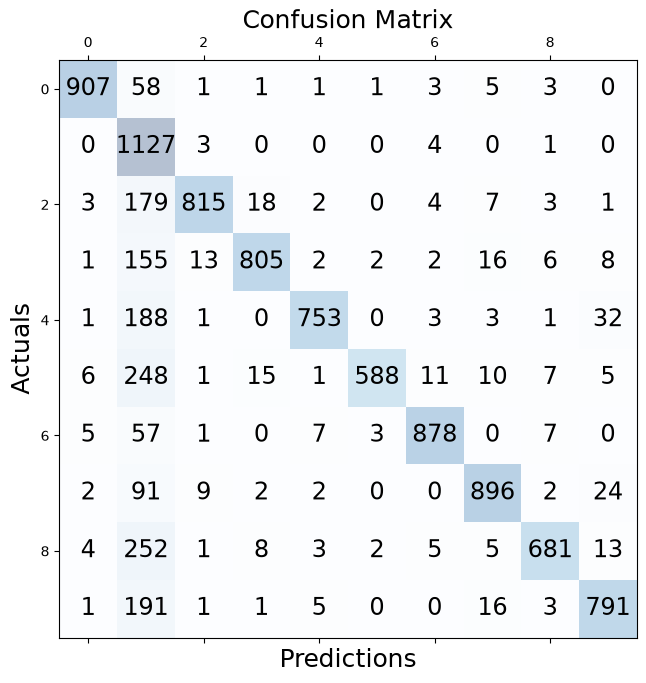

In [12]:
# Visualize the predictions results by plotting the confusion matrix.
conf_matrix = confusion_matrix(y_true=ground_truth_label.values, y_pred=predict_label)
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va="center", ha="center", size="xx-large")

plt.xlabel("Predictions", fontsize=18)
plt.ylabel("Actuals", fontsize=18)
plt.title("Confusion Matrix", fontsize=18)
plt.show()

In [13]:
# Measure the prediction results quantitatively.
eval_accuracy = accuracy_score(ground_truth_label.values, predict_label)
eval_f1_macro = f1_score(ground_truth_label.values, predict_label, average="macro")
eval_f1_micro = f1_score(ground_truth_label.values, predict_label, average="micro")

print(
    f"{bold}Evaluation result on test data{unbold}:{newline}"
    f"{bold}{accuracy_score.__name__}{unbold}: {eval_accuracy}{newline}"
    f"{bold}F1 Macro{unbold}: {eval_f1_macro}{newline}"
    f"{bold}F1 Micro{unbold}: {eval_f1_micro}{newline}"
)

Evaluation result on test data:
accuracy_score: 0.8241
F1 Macro: 0.8431965492275548
F1 Micro: 0.8241



---
Next, we delete the endpoint corresponding to the finetuned model.

---

In [14]:
# Delete the SageMaker endpoint and the attached resources
predictor.delete()
endpoint_config.delete()
tabular_model.delete()

[07/13/26 13:56:41] INFO     Deleting Endpoint -                                                 ]8;id=7309055;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7309056;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\
                             jumpstart-example-lightgbm-classificati-2026-07-13-20-53-02-894                       

                    INFO     Deleting EndpointConfig -                                           ]8;id=7309062;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7309063;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\
                             jumpstart-example-lightgbm-classificati-2026-07-13-20-53-02-894                       

                    INFO     Deleting Model -                                                    ]8;id=7309069;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=7309070;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\
                             jumpstart-example-lightgbm-classificati-2026-07-13-20-53-02-894                       

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/build_and_train_models|sm-lightgbm_catboost_tabular_classification.ipynb)
